# Fit Prediction with Neural Networks (MLP)

This notebook trains neural models to predict fit labels:
- `small`
- `fit` (correct)
- `large`

We use two neural options:
1. **Entity-Embedding MLP (PyTorch)** — recommended for mixed tabular data
2. **One-Hot MLP (Scikit-learn baseline)** — simple neural baseline

Datasets used:
- `Data/modcloth_final_data.json`
- `Data/renttherunway_final_data.json`

In [1]:
import re
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
def convert_height_modcloth(height_str):
    if pd.isna(height_str):
        return np.nan
    try:
        parts = str(height_str).split("ft")
        feet = int(parts[0].strip())
        inches = 0
        if len(parts) > 1 and "in" in parts[1]:
            inches = int(parts[1].replace("in", "").strip())
        value = feet * 12 + inches
        return value if 48 <= value <= 84 else np.nan
    except Exception:
        return np.nan


def convert_height_rtr(height_str):
    if pd.isna(height_str):
        return np.nan
    try:
        match = re.match(r"(\d+)'\s*(\d*)", str(height_str))
        if not match:
            return np.nan
        feet = int(match.group(1))
        inches = int(match.group(2)) if match.group(2) else 0
        value = feet * 12 + inches
        return value if 48 <= value <= 84 else np.nan
    except Exception:
        return np.nan


def load_and_clean_modcloth(path):
    df = pd.read_json(path, lines=True)

    df["height_inches"] = df["height"].apply(convert_height_modcloth)
    df["bust"] = pd.to_numeric(df["bust"].astype(str).str.extract(r"(\d+)")[0], errors="coerce")

    for col in ["waist", "hips", "bra size", "shoe size", "quality"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df["cup size"] = df["cup size"].astype(str).str.lower().str.strip()
    df["cup size"] = df["cup size"].replace({"nan": np.nan})
    df["cup size"] = df["cup size"].str.split("/").str[0]

    keep_cols = [
        "fit", "size", "quality", "category", "length", "cup size",
        "height_inches", "waist", "hips", "bra size", "bust", "shoe size"
    ]
    keep_cols = [c for c in keep_cols if c in df.columns]
    df = df[keep_cols].copy()

    df = df[df["fit"].isin(["small", "fit", "large"])].copy()
    df.dropna(subset=["fit", "size"], inplace=True)
    return df


def load_and_clean_rtr(path):
    df = pd.read_json(path, lines=True)

    df["height_inches"] = df["height"].apply(convert_height_rtr)
    df["weight_lbs"] = pd.to_numeric(df["weight"].astype(str).str.replace("lbs", "", regex=False).str.strip(), errors="coerce")
    df["bra_size"] = pd.to_numeric(df["bust size"].astype(str).str.extract(r"(\d+)")[0], errors="coerce")
    df["cup_size"] = df["bust size"].astype(str).str.extract(r"(\d+)([a-zA-Z+]+)$")[1]
    df["review_date"] = pd.to_datetime(df["review_date"], format="%B %d, %Y", errors="coerce")
    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    df.loc[(df["age"] < 14) | (df["age"] > 90), "age"] = np.nan

    keep_cols = [
        "fit", "size", "rating", "category", "rented for", "body type",
        "cup_size", "height_inches", "weight_lbs", "age", "bra_size"
    ]
    keep_cols = [c for c in keep_cols if c in df.columns]
    df = df[keep_cols].copy()

    df = df[df["fit"].isin(["small", "fit", "large"])].copy()
    df.dropna(subset=["fit", "size"], inplace=True)
    return df

In [3]:
# Experiment configuration
USE_SAMPLE = True
SAMPLE_FRAC_MODCLOTH = 0.50
SAMPLE_FRAC_RTR = 0.40

TARGET_COL = "fit"

modcloth_df = load_and_clean_modcloth("Data/modcloth_final_data.json")
rtr_df = load_and_clean_rtr("Data/renttherunway_final_data.json")

if USE_SAMPLE:
    modcloth_df = modcloth_df.sample(frac=SAMPLE_FRAC_MODCLOTH, random_state=SEED)
    rtr_df = rtr_df.sample(frac=SAMPLE_FRAC_RTR, random_state=SEED)

print("Shapes after cleaning / sampling:")
print(f"ModCloth: {modcloth_df.shape}")
print(f"RentTheRunway: {rtr_df.shape}")

print("\nClass distribution (%):")
print("ModCloth:")
print(modcloth_df[TARGET_COL].value_counts(normalize=True).mul(100).round(2))
print("\nRTR:")
print(rtr_df[TARGET_COL].value_counts(normalize=True).mul(100).round(2))

Shapes after cleaning / sampling:
ModCloth: (41395, 12)
RentTheRunway: (77018, 11)

Class distribution (%):
ModCloth:
fit
fit      68.59
large    15.79
small    15.62
Name: proportion, dtype: float64

RTR:
fit
fit      73.45
small    13.59
large    12.96
Name: proportion, dtype: float64


## Entity-Embedding MLP (PyTorch)

In [4]:
def split_data(df, target_col="fit", random_state=42):
    X = df.drop(columns=[target_col]).copy()
    y = df[target_col].copy()

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.20, random_state=random_state, stratify=y
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=0.20,
        random_state=random_state,
        stratify=y_train_full,
    )

    return X_train, X_val, X_test, y_train, y_val, y_test


def prepare_tabular_tensors(X_train, X_val, X_test, y_train, y_val, y_test):
    num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
    cat_cols = [c for c in X_train.columns if c not in num_cols]

    X_train_num = X_train[num_cols].copy()
    X_val_num = X_val[num_cols].copy()
    X_test_num = X_test[num_cols].copy()

    X_train_cat = X_train[cat_cols].copy()
    X_val_cat = X_val[cat_cols].copy()
    X_test_cat = X_test[cat_cols].copy()

    num_imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    X_train_num_imp = num_imputer.fit_transform(X_train_num)
    X_val_num_imp = num_imputer.transform(X_val_num)
    X_test_num_imp = num_imputer.transform(X_test_num)

    X_train_num_scaled = scaler.fit_transform(X_train_num_imp)
    X_val_num_scaled = scaler.transform(X_val_num_imp)
    X_test_num_scaled = scaler.transform(X_test_num_imp)

    cat_maps = {}
    for col in cat_cols:
        train_col = X_train_cat[col].fillna("Unknown").astype(str)
        categories = pd.Index(train_col.unique()).tolist()
        if "Unknown" not in categories:
            categories.append("Unknown")
        mapping = {v: i for i, v in enumerate(categories)}
        cat_maps[col] = mapping

        X_train_cat[col] = X_train_cat[col].fillna("Unknown").astype(str).map(mapping).fillna(mapping["Unknown"]).astype(int)
        X_val_cat[col] = X_val_cat[col].fillna("Unknown").astype(str).map(mapping).fillna(mapping["Unknown"]).astype(int)
        X_test_cat[col] = X_test_cat[col].fillna("Unknown").astype(str).map(mapping).fillna(mapping["Unknown"]).astype(int)

    label_encoder = LabelEncoder()
    y_train_enc = label_encoder.fit_transform(y_train)
    y_val_enc = label_encoder.transform(y_val)
    y_test_enc = label_encoder.transform(y_test)

    data = {
        "X_train_num": X_train_num_scaled.astype(np.float32),
        "X_val_num": X_val_num_scaled.astype(np.float32),
        "X_test_num": X_test_num_scaled.astype(np.float32),
        "X_train_cat": X_train_cat.values.astype(np.int64),
        "X_val_cat": X_val_cat.values.astype(np.int64),
        "X_test_cat": X_test_cat.values.astype(np.int64),
        "y_train": y_train_enc.astype(np.int64),
        "y_val": y_val_enc.astype(np.int64),
        "y_test": y_test_enc.astype(np.int64),
        "num_cols": num_cols,
        "cat_cols": cat_cols,
        "cat_maps": cat_maps,
        "label_encoder": label_encoder,
    }
    return data

In [5]:
class TabularDataset(Dataset):
    def __init__(self, X_num, X_cat, y):
        self.X_num = torch.tensor(X_num, dtype=torch.float32)
        self.X_cat = torch.tensor(X_cat, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_num[idx], self.X_cat[idx], self.y[idx]


class EntityEmbeddingMLP(nn.Module):
    def __init__(self, num_numeric, cat_cardinalities, hidden_dims=(256, 128, 64), dropout=0.3, num_classes=3):
        super().__init__()

        self.emb_layers = nn.ModuleList()
        emb_output_dim = 0
        for card in cat_cardinalities:
            emb_dim = min(50, max(4, int(round(1.6 * (card ** 0.56)))))
            self.emb_layers.append(nn.Embedding(card, emb_dim))
            emb_output_dim += emb_dim

        input_dim = num_numeric + emb_output_dim

        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, num_classes))

        self.mlp = nn.Sequential(*layers)

    def forward(self, x_num, x_cat):
        if x_cat.shape[1] > 0:
            embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.emb_layers)]
            x = torch.cat([x_num] + embs, dim=1)
        else:
            x = x_num
        return self.mlp(x)


def train_embedding_mlp(prepped, epochs=20, batch_size=1024, lr=1e-3, weight_decay=1e-4, patience=4):
    train_ds = TabularDataset(prepped["X_train_num"], prepped["X_train_cat"], prepped["y_train"])
    val_ds = TabularDataset(prepped["X_val_num"], prepped["X_val_cat"], prepped["y_val"])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    cat_cardinalities = [len(prepped["cat_maps"][c]) for c in prepped["cat_cols"]]
    model = EntityEmbeddingMLP(
        num_numeric=prepped["X_train_num"].shape[1],
        cat_cardinalities=cat_cardinalities,
        num_classes=len(prepped["label_encoder"].classes_),
    ).to(device)

    class_counts = np.bincount(prepped["y_train"])
    class_weights = class_counts.sum() / (len(class_counts) * class_counts)
    class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "val_loss": [], "val_macro_f1": []}
    best_f1 = -1
    best_state = None
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for xb_num, xb_cat, yb in train_loader:
            xb_num, xb_cat, yb = xb_num.to(device), xb_cat.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb_num, xb_cat)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        y_true, y_pred = [], []
        with torch.no_grad():
            for xb_num, xb_cat, yb in val_loader:
                xb_num, xb_cat, yb = xb_num.to(device), xb_cat.to(device), yb.to(device)
                logits = model(xb_num, xb_cat)
                loss = criterion(logits, yb)
                val_losses.append(loss.item())

                preds = torch.argmax(logits, dim=1)
                y_true.extend(yb.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        val_macro_f1 = f1_score(y_true, y_pred, average="macro")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_macro_f1"].append(val_macro_f1)

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_macro_f1={val_macro_f1:.4f}")

        if val_macro_f1 > best_f1:
            best_f1 = val_macro_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print("Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

In [6]:
def evaluate_embedding_mlp(model, prepped, split="test"):
    if split == "test":
        X_num = prepped["X_test_num"]
        X_cat = prepped["X_test_cat"]
        y_true = prepped["y_test"]
    elif split == "val":
        X_num = prepped["X_val_num"]
        X_cat = prepped["X_val_cat"]
        y_true = prepped["y_val"]
    else:
        raise ValueError("split must be 'val' or 'test'")

    model.eval()
    with torch.no_grad():
        x_num_t = torch.tensor(X_num, dtype=torch.float32, device=device)
        x_cat_t = torch.tensor(X_cat, dtype=torch.long, device=device)
        logits = model(x_num_t, x_cat_t)
        y_pred = torch.argmax(logits, dim=1).cpu().numpy()

    classes = prepped["label_encoder"].classes_
    y_true_lbl = prepped["label_encoder"].inverse_transform(y_true)
    y_pred_lbl = prepped["label_encoder"].inverse_transform(y_pred)

    metrics = {
        "accuracy": accuracy_score(y_true_lbl, y_pred_lbl),
        "macro_f1": f1_score(y_true_lbl, y_pred_lbl, average="macro"),
    }

    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Macro-F1: {metrics['macro_f1']:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true_lbl, y_pred_lbl, digits=4))

    cm = confusion_matrix(y_true_lbl, y_pred_lbl, labels=["small", "fit", "large"])
    cm_df = pd.DataFrame(cm, index=["small", "fit", "large"], columns=["small", "fit", "large"])

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix ({split})")
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    return metrics, cm_df


def plot_training_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(history["train_loss"], label="train_loss")
    axes[0].plot(history["val_loss"], label="val_loss")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history["val_macro_f1"], label="val_macro_f1", color="green")
    axes[1].set_title(f"{title} - Validation Macro-F1")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def run_embedding_experiment(df, dataset_name, epochs=20):
    print(f"\n{'='*70}\nEntity-Embedding MLP | {dataset_name}\n{'='*70}")

    X_train, X_val, X_test, y_train, y_val, y_test = split_data(df, target_col="fit", random_state=SEED)
    prepped = prepare_tabular_tensors(X_train, X_val, X_test, y_train, y_val, y_test)

    model, history = train_embedding_mlp(prepped, epochs=epochs)
    plot_training_history(history, dataset_name)
    metrics, cm_df = evaluate_embedding_mlp(model, prepped, split="test")

    return {
        "dataset": dataset_name,
        "model": "EntityEmbeddingMLP",
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
    }


Entity-Embedding MLP | ModCloth
Epoch 01 | train_loss=1.0919 | val_loss=1.0317 | val_macro_f1=0.4424
Epoch 02 | train_loss=1.0472 | val_loss=1.0075 | val_macro_f1=0.4555
Epoch 03 | train_loss=1.0277 | val_loss=0.9986 | val_macro_f1=0.4596
Epoch 04 | train_loss=1.0191 | val_loss=0.9981 | val_macro_f1=0.4569
Epoch 05 | train_loss=1.0117 | val_loss=0.9941 | val_macro_f1=0.4556
Epoch 06 | train_loss=1.0071 | val_loss=0.9936 | val_macro_f1=0.4577
Epoch 07 | train_loss=1.0068 | val_loss=0.9915 | val_macro_f1=0.4557
Early stopping triggered.


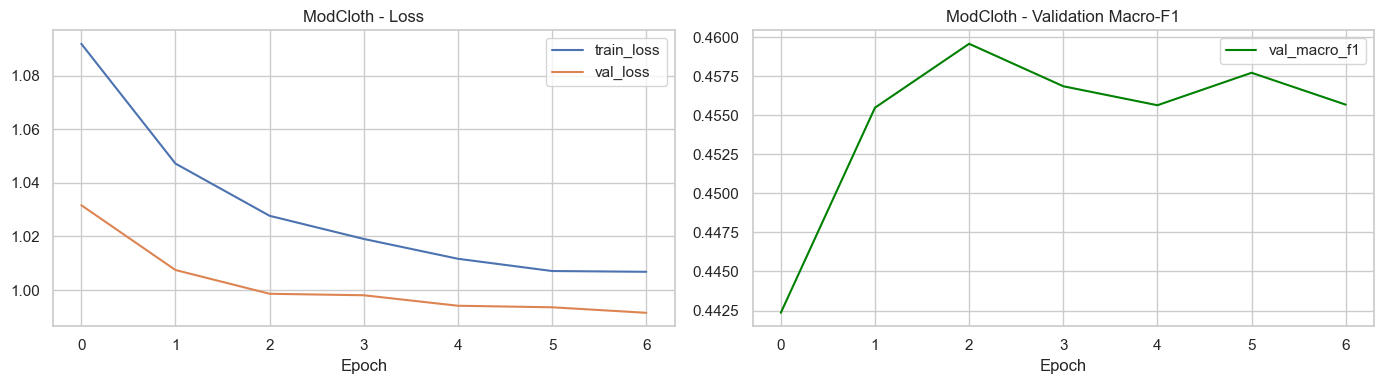

Accuracy: 0.5388
Macro-F1: 0.4584

Classification Report:
              precision    recall  f1-score   support

         fit     0.7918    0.5747    0.6661      5679
       large     0.3011    0.4591    0.3636      1307
       small     0.2759    0.4617    0.3454      1293

    accuracy                         0.5388      8279
   macro avg     0.4563    0.4985    0.4584      8279
weighted avg     0.6338    0.5388    0.5682      8279



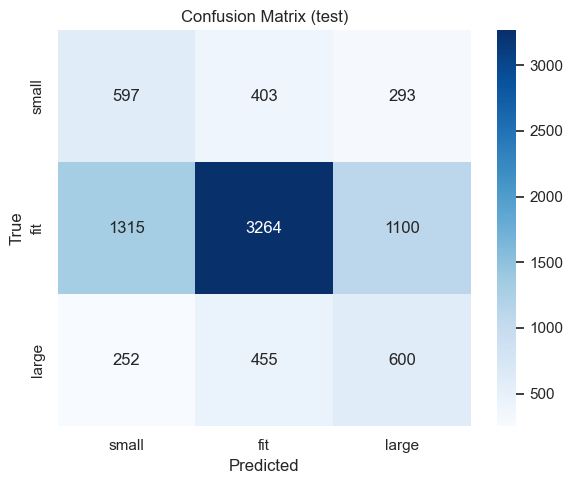


Entity-Embedding MLP | RentTheRunway
Epoch 01 | train_loss=1.0853 | val_loss=1.0311 | val_macro_f1=0.4134
Epoch 02 | train_loss=1.0431 | val_loss=1.0144 | val_macro_f1=0.4058
Epoch 03 | train_loss=1.0295 | val_loss=1.0033 | val_macro_f1=0.4135
Epoch 04 | train_loss=1.0165 | val_loss=0.9954 | val_macro_f1=0.4172
Epoch 05 | train_loss=1.0051 | val_loss=0.9938 | val_macro_f1=0.4202
Epoch 06 | train_loss=0.9998 | val_loss=0.9935 | val_macro_f1=0.4198
Epoch 07 | train_loss=0.9977 | val_loss=0.9923 | val_macro_f1=0.4044
Epoch 08 | train_loss=0.9963 | val_loss=0.9852 | val_macro_f1=0.4166
Epoch 09 | train_loss=0.9913 | val_loss=0.9845 | val_macro_f1=0.4177
Early stopping triggered.


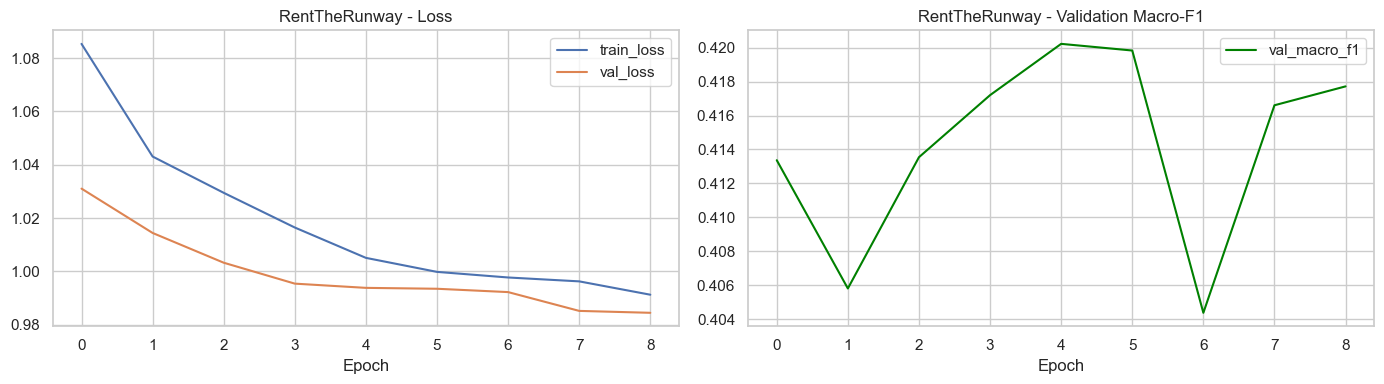

Accuracy: 0.5036
Macro-F1: 0.4246

Classification Report:
              precision    recall  f1-score   support

         fit     0.8329    0.5040    0.6280     11314
       large     0.2408    0.4198    0.3061      1996
       small     0.2399    0.5817    0.3397      2094

    accuracy                         0.5036     15404
   macro avg     0.4379    0.5018    0.4246     15404
weighted avg     0.6756    0.5036    0.5471     15404



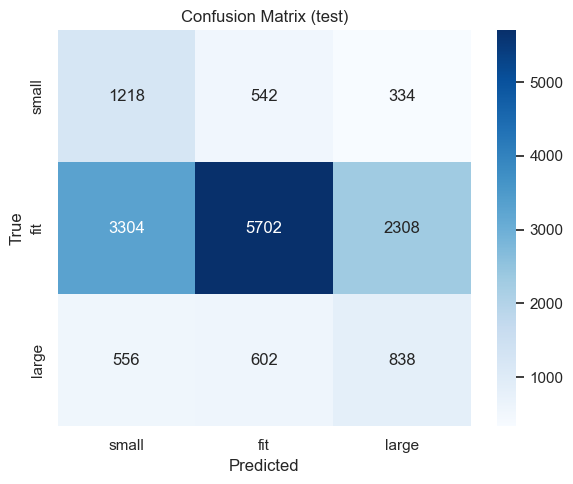

,dataset,model,accuracy,macro_f1
0,ModCloth,EntityEmbeddingMLP,0.538833,0.458359
1,RentTheRunway,EntityEmbeddingMLP,0.503635,0.424564


In [7]:
embedding_results = []

embedding_results.append(run_embedding_experiment(modcloth_df, "ModCloth", epochs=15))
embedding_results.append(run_embedding_experiment(rtr_df, "RentTheRunway", epochs=15))

embedding_results_df = pd.DataFrame(embedding_results)
embedding_results_df

## One-Hot MLP Baseline (Scikit-learn)


Sklearn One-Hot MLP | ModCloth
Accuracy: 0.7031
Macro-F1: 0.4003

Classification Report:
              precision    recall  f1-score   support

         fit     0.7111    0.9727    0.8216      5679
       large     0.5615    0.1362    0.2192      1307
       small     0.6134    0.0920    0.1601      1293

    accuracy                         0.7031      8279
   macro avg     0.6287    0.4003    0.4003      8279
weighted avg     0.6722    0.7031    0.6232      8279



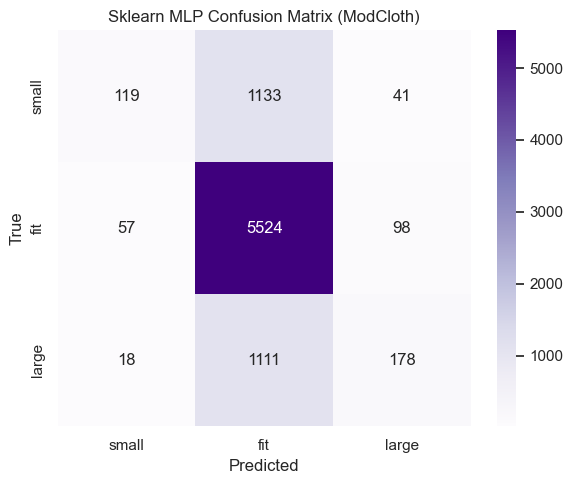


Sklearn One-Hot MLP | RentTheRunway
Accuracy: 0.7345
Macro-F1: 0.3662

Classification Report:
              precision    recall  f1-score   support

         fit     0.7496    0.9734    0.8470     11314
       large     0.4254    0.0757    0.1285      1996
       small     0.4218    0.0721    0.1232      2094

    accuracy                         0.7345     15404
   macro avg     0.5323    0.3737    0.3662     15404
weighted avg     0.6631    0.7345    0.6555     15404



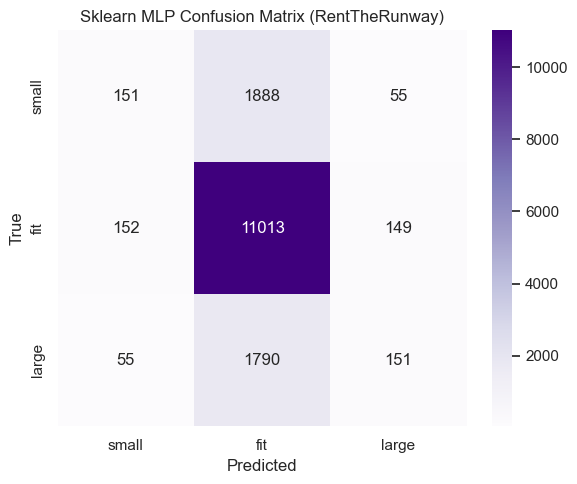

,dataset,model,accuracy,macro_f1
0,ModCloth,SklearnOneHotMLP,0.703104,0.400287
1,RentTheRunway,SklearnOneHotMLP,0.734549,0.366204


In [9]:
def run_sklearn_mlp(df, dataset_name):
    print(f"\n{'='*70}\nSklearn One-Hot MLP | {dataset_name}\n{'='*70}")

    X = df.drop(columns=["fit"]).copy()
    y = df["fit"].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )

    target_encoder = LabelEncoder()
    y_train_enc = target_encoder.fit_transform(y_train)
    y_test_enc = target_encoder.transform(y_test)

    num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
    cat_cols = [c for c in X_train.columns if c not in num_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]), cat_cols),
        ]
    )

    model = MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation="relu",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=40,
        early_stopping=True,
        n_iter_no_change=5,
        random_state=SEED,
        verbose=False,
    )

    clf = Pipeline([
        ("prep", preprocessor),
        ("mlp", model),
    ])

    clf.fit(X_train, y_train_enc)
    y_pred_enc = clf.predict(X_test)

    y_test_lbl = target_encoder.inverse_transform(y_test_enc)
    y_pred_lbl = target_encoder.inverse_transform(y_pred_enc)

    acc = accuracy_score(y_test_lbl, y_pred_lbl)
    macro_f1 = f1_score(y_test_lbl, y_pred_lbl, average="macro")

    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-F1: {macro_f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test_lbl, y_pred_lbl, digits=4))

    cm = confusion_matrix(y_test_lbl, y_pred_lbl, labels=["small", "fit", "large"])
    cm_df = pd.DataFrame(cm, index=["small", "fit", "large"], columns=["small", "fit", "large"])

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Purples")
    plt.title(f"Sklearn MLP Confusion Matrix ({dataset_name})")
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    return {
        "dataset": dataset_name,
        "model": "SklearnOneHotMLP",
        "accuracy": acc,
        "macro_f1": macro_f1,
    }


baseline_results = []
baseline_results.append(run_sklearn_mlp(modcloth_df, "ModCloth"))
baseline_results.append(run_sklearn_mlp(rtr_df, "RentTheRunway"))

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df

In [10]:
# Compare neural options
comparison_df = pd.concat([embedding_results_df, baseline_results_df], ignore_index=True)
comparison_df = comparison_df.sort_values(["dataset", "macro_f1"], ascending=[True, False])
comparison_df

,dataset,model,accuracy,macro_f1
0,ModCloth,EntityEmbeddingMLP,0.538833,0.458359
2,ModCloth,SklearnOneHotMLP,0.703104,0.400287
1,RentTheRunway,EntityEmbeddingMLP,0.503635,0.424564
3,RentTheRunway,SklearnOneHotMLP,0.734549,0.366204


In [11]:
# Auto-summary of best model choices
best_macro = comparison_df.loc[comparison_df.groupby("dataset")["macro_f1"].idxmax()][["dataset", "model", "macro_f1"]]
best_acc = comparison_df.loc[comparison_df.groupby("dataset")["accuracy"].idxmax()][["dataset", "model", "accuracy"]]

print("Best model by Macro-F1 (balanced fit quality):")
print(best_macro.to_string(index=False))

print("\nBest model by Accuracy (majority-class weighted):")
print(best_acc.to_string(index=False))

Best model by Macro-F1 (balanced fit quality):
      dataset              model  macro_f1
     ModCloth EntityEmbeddingMLP  0.458359
RentTheRunway EntityEmbeddingMLP  0.424564

Best model by Accuracy (majority-class weighted):
      dataset            model  accuracy
     ModCloth SklearnOneHotMLP  0.703104
RentTheRunway SklearnOneHotMLP  0.734549


## Notes and Next Iterations

- For final training, set `USE_SAMPLE = False` to use full data.
- Tune `hidden_dims`, `dropout`, `batch_size`, and `epochs` to improve macro-F1.
- If `small` / `large` recall is low, increase class weighting strength or use focal loss.
- Consider adding text-derived features from `review_text` (e.g., TF-IDF or transformer embeddings) for better edge-case fit predictions.

## Full-Data Iteration: Focal Loss + Hyperparameter Sweep

This section runs a second iteration on **full datasets** (`USE_SAMPLE=False`) using:
- weighted cross-entropy and focal loss variants
- a compact hyperparameter sweep
- selection by validation **Macro-F1** (tie-break: minority recall for `small`/`large`)

In [12]:
# Reload full cleaned datasets (no sampling)
modcloth_full_df = load_and_clean_modcloth("Data/modcloth_final_data.json")
rtr_full_df = load_and_clean_rtr("Data/renttherunway_final_data.json")

print("Full dataset shapes:")
print(f"ModCloth full: {modcloth_full_df.shape}")
print(f"RentTheRunway full: {rtr_full_df.shape}")

print("\nClass distribution (full):")
print("ModCloth:")
print(modcloth_full_df["fit"].value_counts(normalize=True).mul(100).round(2))
print("\nRTR:")
print(rtr_full_df["fit"].value_counts(normalize=True).mul(100).round(2))

Full dataset shapes:
ModCloth full: (82790, 12)
RentTheRunway full: (192544, 11)

Class distribution (full):
ModCloth:
fit
fit      68.56
large    15.77
small    15.67
Name: proportion, dtype: float64

RTR:
fit
fit      73.78
small    13.39
large    12.83
Name: proportion, dtype: float64


In [13]:
import torch.nn.functional as F


class FocalLoss(nn.Module):
    def __init__(self, class_weights=None, gamma=2.0):
        super().__init__()
        self.class_weights = class_weights
        self.gamma = gamma

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, weight=self.class_weights, reduction="none")
        pt = torch.exp(-ce_loss)
        focal = ((1 - pt) ** self.gamma) * ce_loss
        return focal.mean()


def get_split_predictions(model, prepped, split="val"):
    if split == "val":
        X_num, X_cat, y_true = prepped["X_val_num"], prepped["X_val_cat"], prepped["y_val"]
    elif split == "test":
        X_num, X_cat, y_true = prepped["X_test_num"], prepped["X_test_cat"], prepped["y_test"]
    else:
        raise ValueError("split must be 'val' or 'test'")

    model.eval()
    with torch.no_grad():
        x_num_t = torch.tensor(X_num, dtype=torch.float32, device=device)
        x_cat_t = torch.tensor(X_cat, dtype=torch.long, device=device)
        logits = model(x_num_t, x_cat_t)
        y_pred = torch.argmax(logits, dim=1).cpu().numpy()

    label_encoder = prepped["label_encoder"]
    y_true_lbl = label_encoder.inverse_transform(y_true)
    y_pred_lbl = label_encoder.inverse_transform(y_pred)
    return y_true_lbl, y_pred_lbl


def minority_recall_score(y_true_lbl, y_pred_lbl):
    report = classification_report(y_true_lbl, y_pred_lbl, output_dict=True, zero_division=0)
    return float((report.get("small", {}).get("recall", 0.0) + report.get("large", {}).get("recall", 0.0)) / 2)


def train_embedding_mlp_advanced(prepped, config):
    train_ds = TabularDataset(prepped["X_train_num"], prepped["X_train_cat"], prepped["y_train"])
    val_ds = TabularDataset(prepped["X_val_num"], prepped["X_val_cat"], prepped["y_val"])

    train_loader = DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=config["batch_size"], shuffle=False)

    cat_cardinalities = [len(prepped["cat_maps"][c]) for c in prepped["cat_cols"]]
    model = EntityEmbeddingMLP(
        num_numeric=prepped["X_train_num"].shape[1],
        cat_cardinalities=cat_cardinalities,
        hidden_dims=config["hidden_dims"],
        dropout=config["dropout"],
        num_classes=len(prepped["label_encoder"].classes_),
    ).to(device)

    class_counts = np.bincount(prepped["y_train"])
    class_weights = class_counts.sum() / (len(class_counts) * class_counts)
    class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)

    if config["loss_type"] == "focal":
        criterion = FocalLoss(class_weights=class_weights_t, gamma=config.get("gamma", 2.0))
    else:
        criterion = nn.CrossEntropyLoss(weight=class_weights_t)

    optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config.get("weight_decay", 1e-4))

    best_state = None
    best_val_macro_f1 = -1
    best_val_minority_recall = -1
    bad_epochs = 0

    history = {"train_loss": [], "val_loss": [], "val_macro_f1": []}

    for epoch in range(1, config["epochs"] + 1):
        model.train()
        train_losses = []
        for xb_num, xb_cat, yb in train_loader:
            xb_num, xb_cat, yb = xb_num.to(device), xb_cat.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb_num, xb_cat)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        y_true, y_pred = [], []
        with torch.no_grad():
            for xb_num, xb_cat, yb in val_loader:
                xb_num, xb_cat, yb = xb_num.to(device), xb_cat.to(device), yb.to(device)
                logits = model(xb_num, xb_cat)
                loss = criterion(logits, yb)
                val_losses.append(loss.item())
                preds = torch.argmax(logits, dim=1)
                y_true.extend(yb.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())

        val_macro_f1 = f1_score(y_true, y_pred, average="macro")
        y_true_lbl = prepped["label_encoder"].inverse_transform(np.array(y_true))
        y_pred_lbl = prepped["label_encoder"].inverse_transform(np.array(y_pred))
        val_minority_recall = minority_recall_score(y_true_lbl, y_pred_lbl)

        history["train_loss"].append(float(np.mean(train_losses)))
        history["val_loss"].append(float(np.mean(val_losses)))
        history["val_macro_f1"].append(val_macro_f1)

        improved = (
            (val_macro_f1 > best_val_macro_f1) or
            (np.isclose(val_macro_f1, best_val_macro_f1) and val_minority_recall > best_val_minority_recall)
        )

        if improved:
            best_val_macro_f1 = val_macro_f1
            best_val_minority_recall = val_minority_recall
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= config["patience"]:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_val_macro_f1, best_val_minority_recall


def run_full_tuning(df, dataset_name, search_space):
    print(f"\n{'='*80}\nFull-Data Tuning | {dataset_name}\n{'='*80}")

    X_train, X_val, X_test, y_train, y_val, y_test = split_data(df, target_col="fit", random_state=SEED)
    prepped = prepare_tabular_tensors(X_train, X_val, X_test, y_train, y_val, y_test)

    trial_rows = []
    best_model = None
    best_prepped = prepped
    best_cfg = None
    best_key = (-1, -1)

    for i, cfg in enumerate(search_space, 1):
        print(f"\nTrial {i}/{len(search_space)}: {cfg}")
        model, history, val_macro_f1, val_minority_recall = train_embedding_mlp_advanced(prepped, cfg)
        print(f"Val Macro-F1: {val_macro_f1:.4f} | Val minority recall: {val_minority_recall:.4f}")

        trial_rows.append({
            "dataset": dataset_name,
            "trial": i,
            **cfg,
            "val_macro_f1": val_macro_f1,
            "val_minority_recall": val_minority_recall,
        })

        key = (val_macro_f1, val_minority_recall)
        if key > best_key:
            best_key = key
            best_model = model
            best_cfg = cfg

    print("\nBest config:")
    print(best_cfg)

    y_true_test, y_pred_test = get_split_predictions(best_model, best_prepped, split="test")
    test_acc = accuracy_score(y_true_test, y_pred_test)
    test_macro = f1_score(y_true_test, y_pred_test, average="macro")
    test_minority_recall = minority_recall_score(y_true_test, y_pred_test)

    print(f"\nTest Accuracy: {test_acc:.4f}")
    print(f"Test Macro-F1: {test_macro:.4f}")
    print(f"Test minority recall (small/large): {test_minority_recall:.4f}")
    print("\nTest Classification Report:")
    print(classification_report(y_true_test, y_pred_test, digits=4, zero_division=0))

    cm = confusion_matrix(y_true_test, y_pred_test, labels=["small", "fit", "large"])
    cm_df = pd.DataFrame(cm, index=["small", "fit", "large"], columns=["small", "fit", "large"])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Greens")
    plt.title(f"Best Tuned Model Confusion Matrix ({dataset_name})")
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    test_row = {
        "dataset": dataset_name,
        "model": "TunedEntityEmbeddingMLP",
        "accuracy": test_acc,
        "macro_f1": test_macro,
        "minority_recall": test_minority_recall,
        "best_config": str(best_cfg),
    }

    return pd.DataFrame(trial_rows), test_row


Full-Data Tuning | ModCloth

Trial 1/3: {'loss_type': 'ce', 'gamma': 0.0, 'hidden_dims': (256, 128, 64), 'dropout': 0.3, 'lr': 0.001, 'batch_size': 2048, 'epochs': 8, 'patience': 2, 'weight_decay': 0.0001}
Val Macro-F1: 0.4761 | Val minority recall: 0.4426

Trial 2/3: {'loss_type': 'focal', 'gamma': 1.5, 'hidden_dims': (256, 128, 64), 'dropout': 0.3, 'lr': 0.001, 'batch_size': 2048, 'epochs': 8, 'patience': 2, 'weight_decay': 0.0001}
Val Macro-F1: 0.3122 | Val minority recall: 0.6277

Trial 3/3: {'loss_type': 'focal', 'gamma': 2.0, 'hidden_dims': (320, 160, 80), 'dropout': 0.35, 'lr': 0.0008, 'batch_size': 2048, 'epochs': 8, 'patience': 2, 'weight_decay': 0.0001}
Val Macro-F1: 0.3128 | Val minority recall: 0.5707

Best config:
{'loss_type': 'ce', 'gamma': 0.0, 'hidden_dims': (256, 128, 64), 'dropout': 0.3, 'lr': 0.001, 'batch_size': 2048, 'epochs': 8, 'patience': 2, 'weight_decay': 0.0001}

Test Accuracy: 0.5648
Test Macro-F1: 0.4718
Test minority recall (small/large): 0.4437

Test Cl

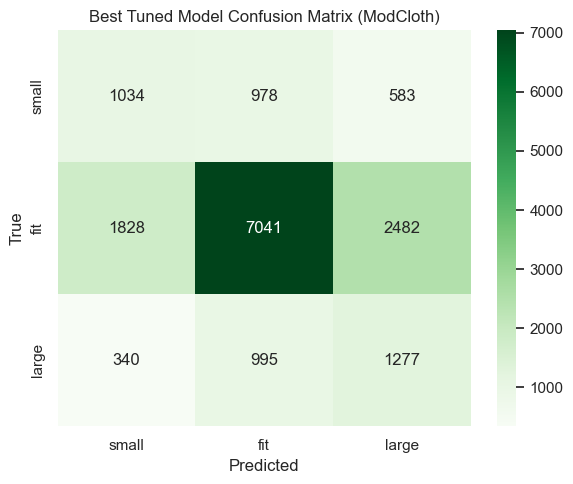


Full-Data Tuning | RentTheRunway

Trial 1/3: {'loss_type': 'ce', 'gamma': 0.0, 'hidden_dims': (256, 128, 64), 'dropout': 0.3, 'lr': 0.001, 'batch_size': 2048, 'epochs': 8, 'patience': 2, 'weight_decay': 0.0001}
Val Macro-F1: 0.4245 | Val minority recall: 0.4731

Trial 2/3: {'loss_type': 'focal', 'gamma': 1.5, 'hidden_dims': (256, 128, 64), 'dropout': 0.3, 'lr': 0.001, 'batch_size': 2048, 'epochs': 8, 'patience': 2, 'weight_decay': 0.0001}
Val Macro-F1: 0.2117 | Val minority recall: 0.6628

Trial 3/3: {'loss_type': 'focal', 'gamma': 2.0, 'hidden_dims': (320, 160, 80), 'dropout': 0.35, 'lr': 0.0008, 'batch_size': 2048, 'epochs': 8, 'patience': 2, 'weight_decay': 0.0001}
Val Macro-F1: 0.1925 | Val minority recall: 0.6947

Best config:
{'loss_type': 'ce', 'gamma': 0.0, 'hidden_dims': (256, 128, 64), 'dropout': 0.3, 'lr': 0.001, 'batch_size': 2048, 'epochs': 8, 'patience': 2, 'weight_decay': 0.0001}

Test Accuracy: 0.5133
Test Macro-F1: 0.4170
Test minority recall (small/large): 0.4567

Te

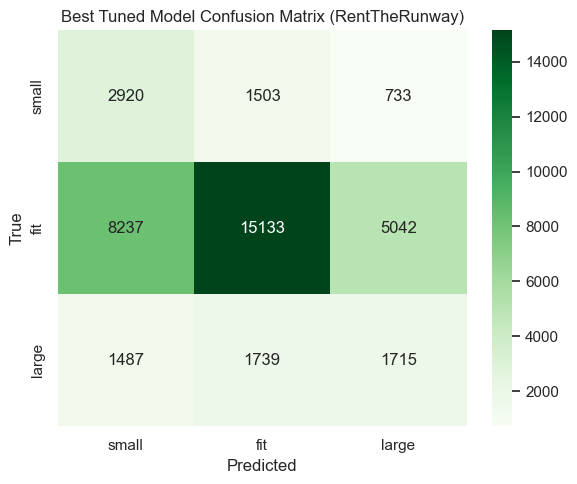


Validation trial leaderboard (top per dataset):


,dataset,trial,loss_type,gamma,hidden_dims,dropout,lr,batch_size,epochs,patience,weight_decay,val_macro_f1,val_minority_recall
0,ModCloth,1,ce,0.0,"(256, 128, 64)",0.30,0.0010,2048,8,2,0.0001,0.476100,0.442566
2,ModCloth,3,focal,2.0,"(320, 160, 80)",0.35,0.0008,2048,8,2,0.0001,0.312829,0.570704
1,ModCloth,2,focal,1.5,"(256, 128, 64)",0.30,0.0010,2048,8,2,0.0001,0.312216,0.627691
3,RentTheRunway,1,ce,0.0,"(256, 128, 64)",0.30,0.0010,2048,8,2,0.0001,0.424476,0.473123
4,RentTheRunway,2,focal,1.5,"(256, 128, 64)",0.30,0.0010,2048,8,2,0.0001,0.211723,0.662783
5,RentTheRunway,3,focal,2.0,"(320, 160, 80)",0.35,0.0008,2048,8,2,0.0001,0.192478,0.694740



Final tuned test results:


,dataset,model,accuracy,macro_f1,minority_recall,best_config
0,ModCloth,TunedEntityEmbeddingMLP,0.564803,0.471829,0.443678,"{'loss_type': 'ce', 'gamma': 0.0, 'hidden_dims..."
1,RentTheRunway,TunedEntityEmbeddingMLP,0.513335,0.416967,0.456713,"{'loss_type': 'ce', 'gamma': 0.0, 'hidden_dims..."


In [14]:
# Compact sweep for CPU-friendly iteration on full data
search_space = [
    {
        "loss_type": "ce",
        "gamma": 0.0,
        "hidden_dims": (256, 128, 64),
        "dropout": 0.30,
        "lr": 1e-3,
        "batch_size": 2048,
        "epochs": 8,
        "patience": 2,
        "weight_decay": 1e-4,
    },
    {
        "loss_type": "focal",
        "gamma": 1.5,
        "hidden_dims": (256, 128, 64),
        "dropout": 0.30,
        "lr": 1e-3,
        "batch_size": 2048,
        "epochs": 8,
        "patience": 2,
        "weight_decay": 1e-4,
    },
    {
        "loss_type": "focal",
        "gamma": 2.0,
        "hidden_dims": (320, 160, 80),
        "dropout": 0.35,
        "lr": 8e-4,
        "batch_size": 2048,
        "epochs": 8,
        "patience": 2,
        "weight_decay": 1e-4,
    },
]

modcloth_trials_df, modcloth_tuned_result = run_full_tuning(modcloth_full_df, "ModCloth", search_space)
rtr_trials_df, rtr_tuned_result = run_full_tuning(rtr_full_df, "RentTheRunway", search_space)

tuning_trials_df = pd.concat([modcloth_trials_df, rtr_trials_df], ignore_index=True)
tuned_results_df = pd.DataFrame([modcloth_tuned_result, rtr_tuned_result])

print("\nValidation trial leaderboard (top per dataset):")
display(tuning_trials_df.sort_values(["dataset", "val_macro_f1", "val_minority_recall"], ascending=[True, False, False]))

print("\nFinal tuned test results:")
display(tuned_results_df)